## Sigmoid

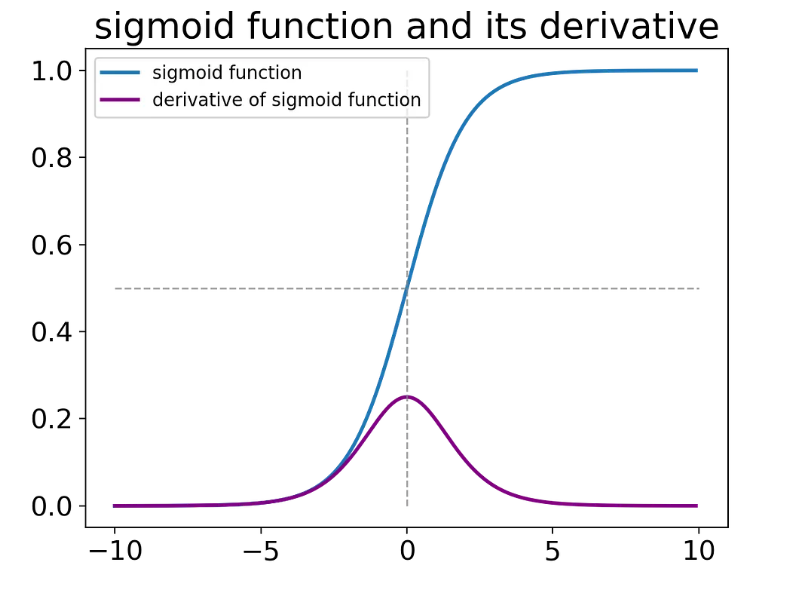

$$
a = \frac{1}{1+e^{-z}}
$$

### Advantages 
- Non linear function 
- Differentaible everywhere
- Range = [0,1] and hence it can be used as estimated probability in output layer

### Disadvantages
- Saturation function 
- Is not zero centered
- computationally expensive 

_Generally we only use sigmoid in output layer only (not in hidden layers)_

## Tanh

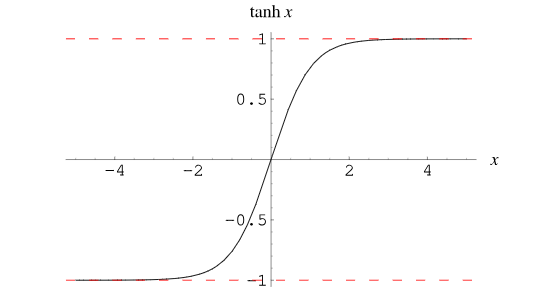

$$
tanh(x) = -i \text{tan}(ix)
$$
$$
tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

Range = [-1,1]

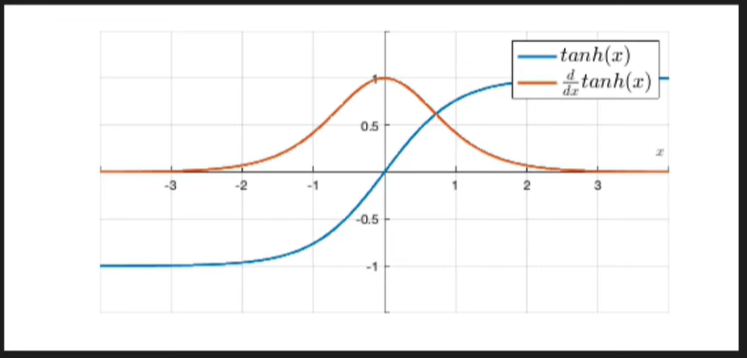

### Advantages
- Zero Centered
- Differentiable
- Non-linear

### Disadvantages
- Saturating function 
- computationally expensive

_Can be used in hidden layers of shallow neural networks if Vanishing Gradient problem is not observed_

## Relu
(Rectified Linear Unit)

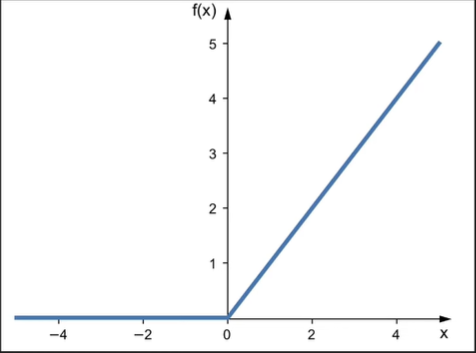

$$
a = max(0,z)
$$

### Advantages
- Non linear
- Non saturating
- Computationally inexpensive
- Convergence is faster

### Disadvantages 
- Non-differentiable: But we make if else statement that if z<0 --> 0 and if z>=0 --> 1
- Not zero centered: but we can use Batch Normalization 

___Why relu works?___  (The doubts thats been eating my brain since i saw this function)  
This is almost a linear function and why does it work when linear function obviously do not work

### _Dying Relu Problem_
This occurs when neurons using Relu activation function permanently outputs 0, And hence neuron is said to be dead. If this happens to >50% of neurons then model wont be able to capture the patterns and perform bad

_Intuition on Why this happens_  
In Relu activation function if the input (summation $z = w_1x_1 + w_2x_2 + b$) is negative, then output is Zero. Hence the derivative of output is also zero - which is supposed to be used by gradient descent to update the weights ---> Hence finally weights do not get updated 

_when this happens_
- $z = w_1x_1 + w_2x_2 + b < 0$
- Bad Weights initialization - weights start in regions where summation is negative
- High learning rate - weights/bias can be pushed to be negative after update if learning rate is high
- High negative bias
- Data distribution - if the inputs to the model are highly negative

_Why neuron stays dead an become permanently dead_  
- 

- Suppose in a iteration t, weights and bias lie in such a region that z<0 for all training samples in that batch. Hence, z<0 --> output = 0 --> derivative = 0 --> no weight update --> neuron is dead
- 


### Solutions for Dying relu problem
- Lower the learing rate
- Initialize bias with enough positive value (experimentally 0.01 is good enough)
- Use variants of Relu

### Variants of Relu
1. Linear variations - Leaky Relu, Parametric Relu
2. Non-linear variations - Exp relu, Selu

- ___Leaky Relu___
$$
f(z) = 
\begin{cases}
z & z>0
\\
0.01z & z>=0
\end{cases}
$$

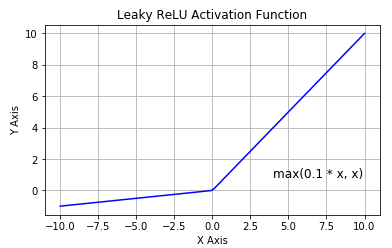

Advantages:  
- Non saturated
- Close to zero centered
- Computationally inexpensive
- Robust to dying relu problem

- ___Parametric Relu___
$$
f(z) = 
\begin{cases}
z & z>0
\\
\alpha z & z>=0
\end{cases}
$$

Advantages:
- Same as leaky relu 
- Here, $\alpha$ is a model parameter, Hence its best value is calculated through training. This is more flexible since $\alpha$ depends on data

- ___Elu___ (Exponential Linear Unit)
$$
f(z) = 
\begin{cases}
z & z>0
\\
\alpha (e^z - 1) & z>=0
\end{cases}
$$

Elu and its derivative 

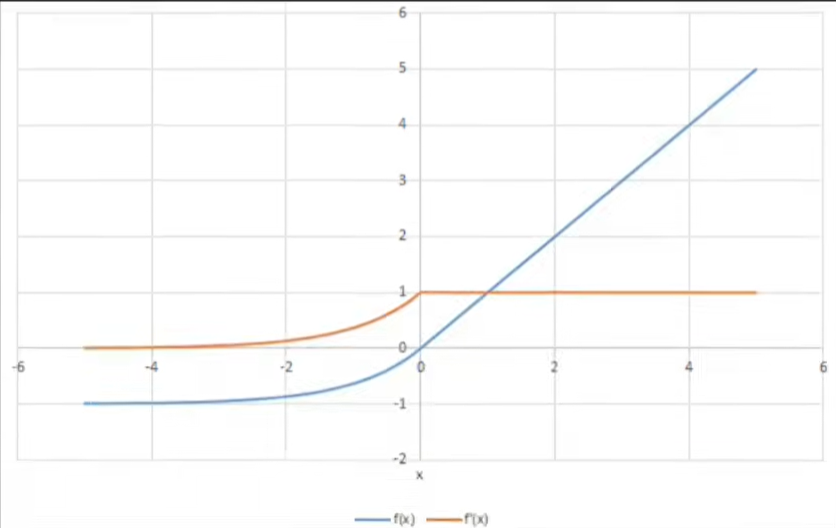

Advantages: 
- Close to zero centered
- No dying relu
- Non saturated
- Always differentiable
- Better in generalization

- ___Selu___ (Scaled Exponential Linear Unit)
$$
f(z) = 
\lambda \begin{cases}
z & z>0
\\
\alpha e^z - \alpha & z>=0
\end{cases}
$$

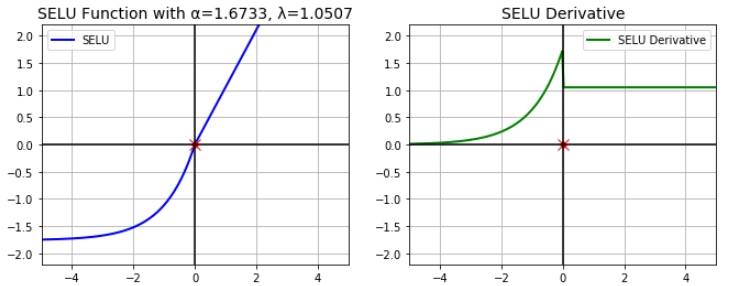
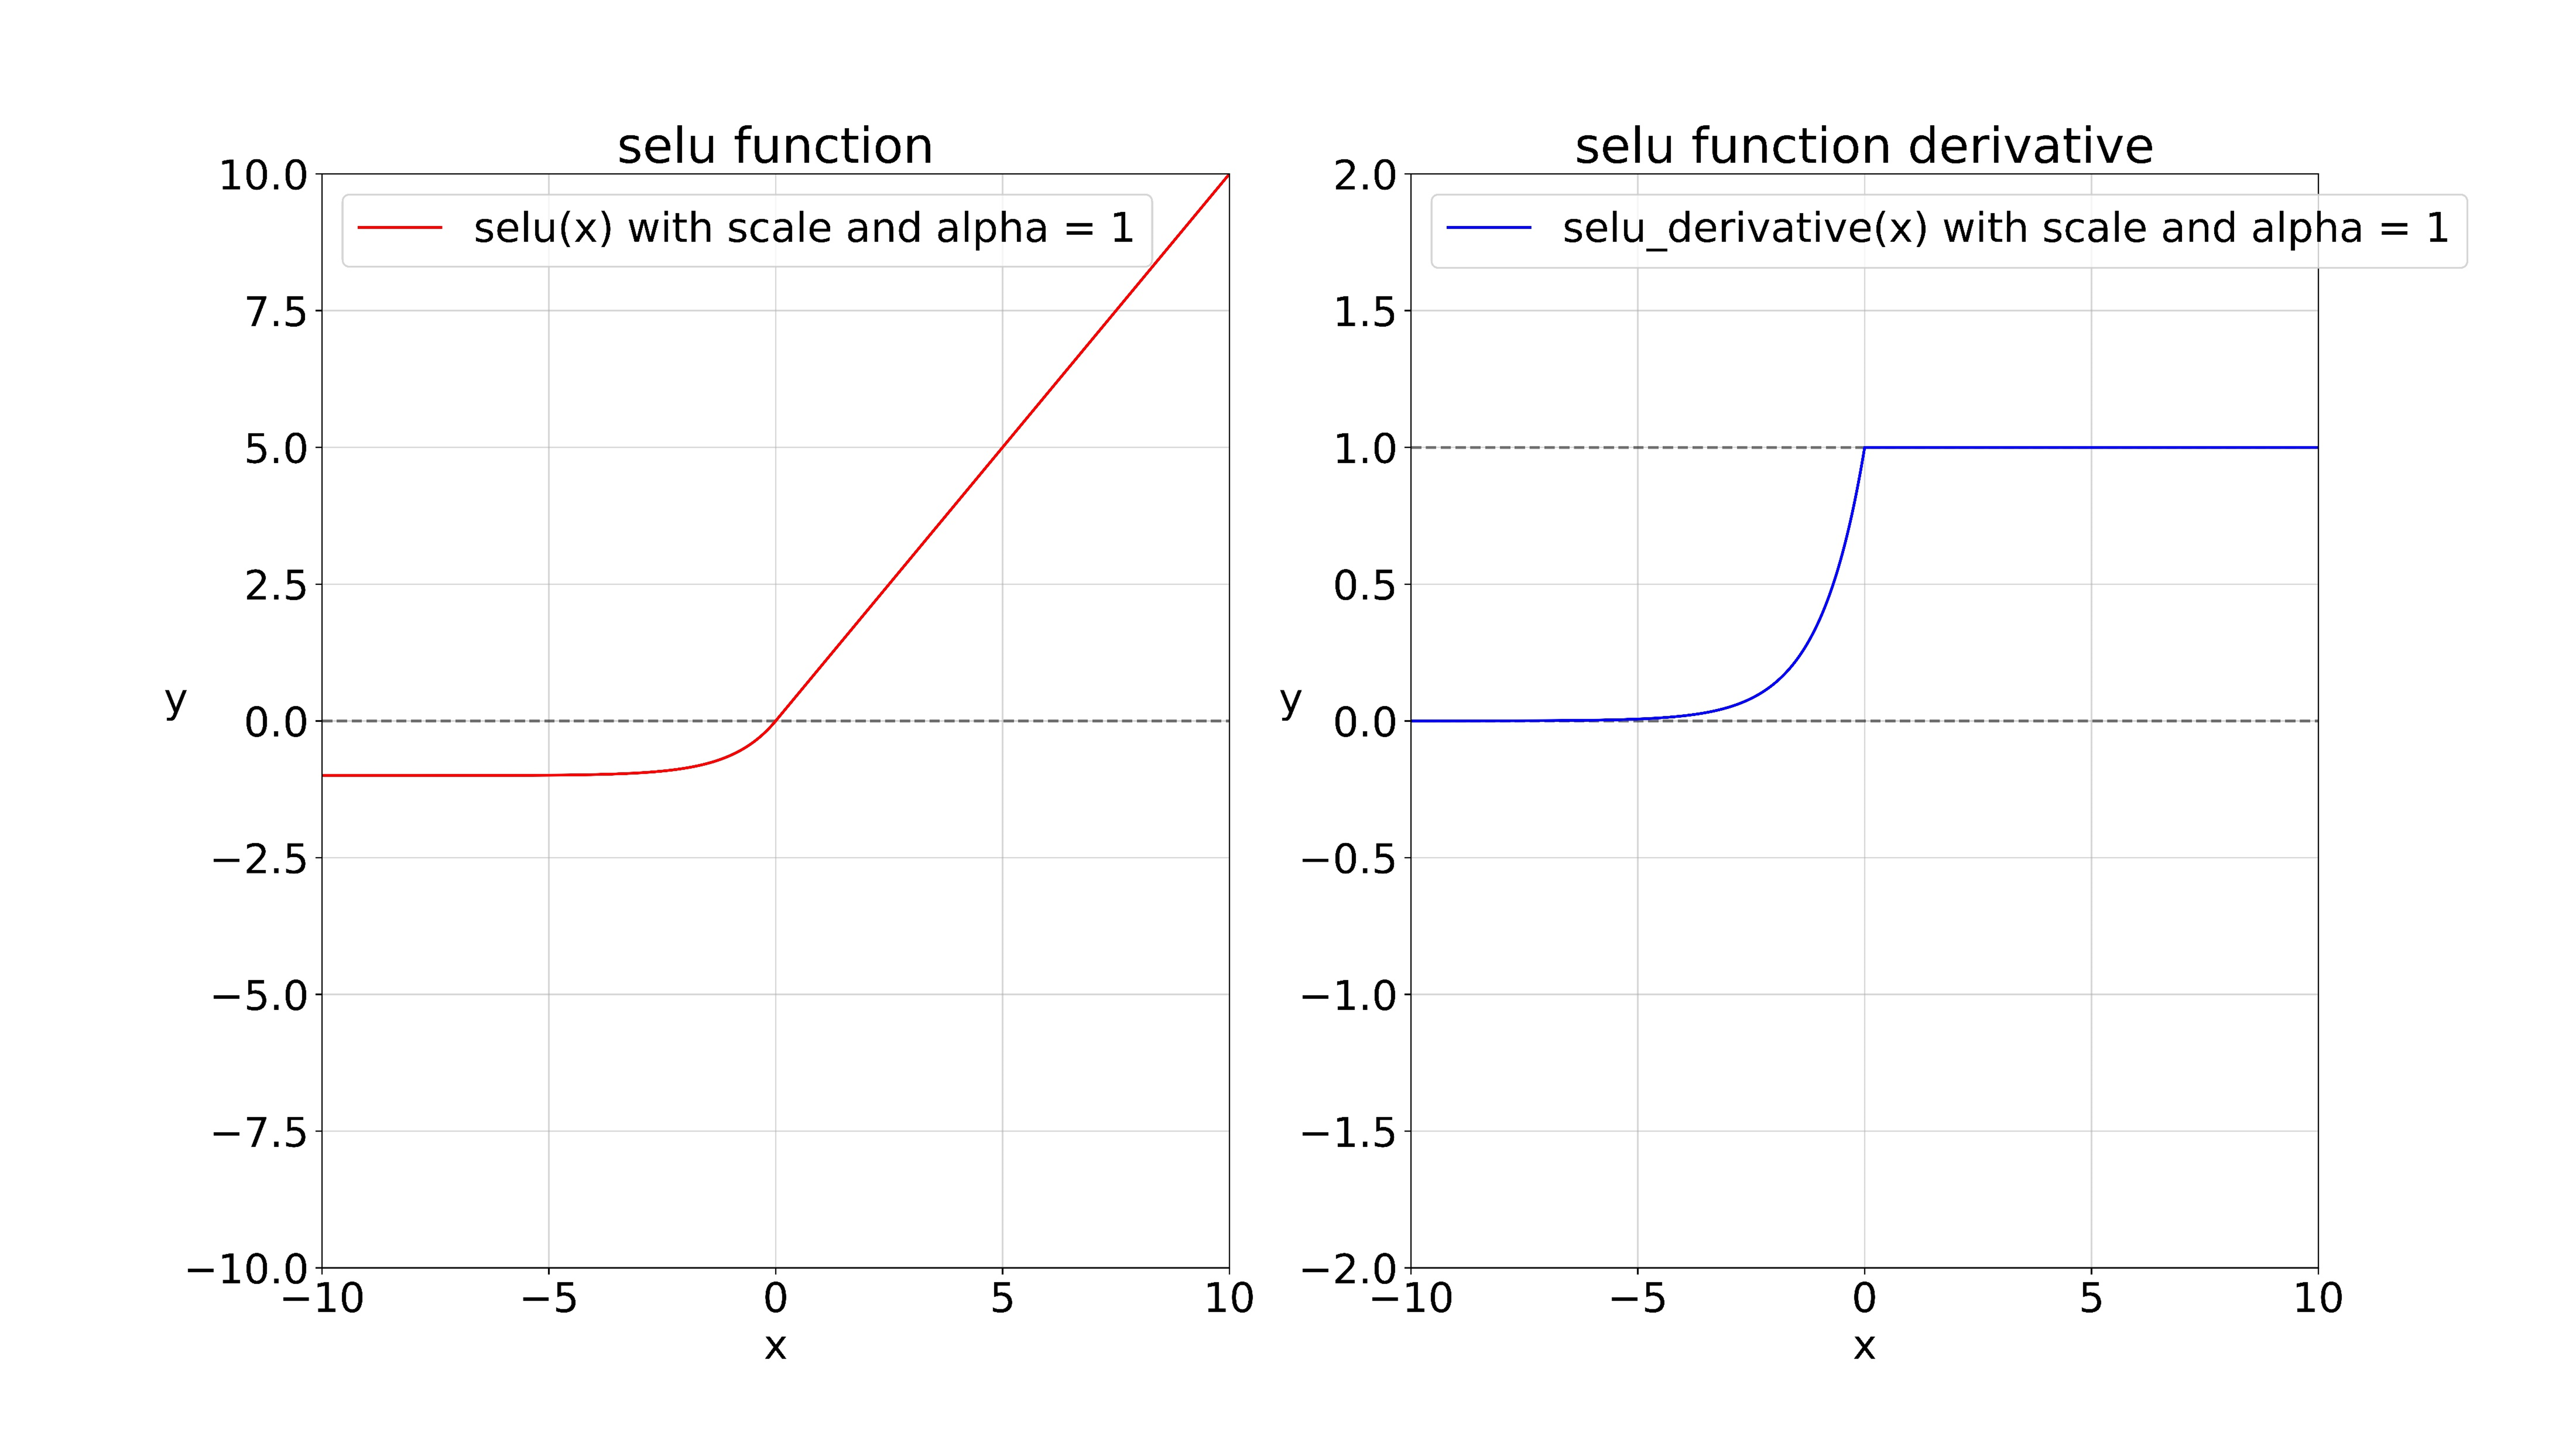

Advantages and disadvantages:
- Comparatively newly discovered
- $\alpha , \lambda$ are fixed parameters 
- sometimes work better than elu 
- Computationally expensive
- Self normalizing - the outputs have mean=0, std=1
- Hence even though they are computationally expensive, even though its computationally expensive, it can converge faster